In [1]:
from pathlib import Path

checkpoint_root = Path("checkpoint")

methods = {
    "StarCE": {
        "csv": checkpoint_root / "StarCE" / "benchmark_times.csv",
        "type": "starce",
        "enabled": True,
    },
    "SafeBound": {
        "csv": checkpoint_root / "SafeBound" / "benchmark_times.csv",
        "type": "safebound",
        "enabled": True,
    },
    "Postgre": {
        "csv": checkpoint_root / "Postgre" / "pg_stats_summary.csv",
        "type": "postgre",
        "enabled": True,
    },
    "FactorJoin": {
        "csv": checkpoint_root / "FactorJoin" / "benchmark_times.csv",
        "type": "factorjoin",
        "enabled": True,
    },
    "LpBound": {
        "csv": checkpoint_root / "LpBound" / "benchmark_times.csv",
        "type": "lpbound",
        "enabled": True,
    },
}

missing_rule = "separate_x"  # "separate_x" or "any_missing_x"

benchmark_alias = {
    "Stats": "STATS",
    "stats": "STATS",
}

benchmark_order = None  # e.g. ["STATS", "JOBM"]

size_unit = "MB"  # "bytes", "KB", "MB"

In [2]:
import math
import pandas as pd
import numpy as np


def normalize_benchmark(name: str) -> str:
    key = str(name).strip()
    if key in benchmark_alias:
        return benchmark_alias[key]
    key_upper = key.upper()
    if key_upper in benchmark_alias:
        return benchmark_alias[key_upper]
    return key


def load_method_data(method_name: str, cfg: dict) -> dict:
    if not cfg.get("enabled", True):
        return {}
    path = Path(cfg["csv"])
    if not path.exists():
        print(f"  Warning: {method_name} CSV file does not exist: {path}")
        return {}
    df = pd.read_csv(path)
    method_type = cfg.get("type", "")

    if method_type == "starce":
        df = df.rename(
            columns={
                "benchmark": "benchmark",
                "build_time_sec": "build_time_sec",
                "statistics_size_bytes": "statistics_size_bytes",
            }
        )
    elif method_type == "safebound":
        df = df.rename(
            columns={
                "Benchmark": "benchmark",
                "BuildTime": "build_time_sec",
                "StatisticsSize": "statistics_size_bytes",
            }
        )
        if "statistics_size_bytes" not in df.columns:
            print(f"  Warning: {method_name} CSV Missing StatisticsSize  column, filled with NaN")
            df["statistics_size_bytes"] = np.nan
    elif method_type == "postgre":
        df = df.rename(
            columns={
                "Benchmark": "benchmark",
                "BuildTime": "build_time_sec",
                "StatisticsSize": "statistics_size_bytes",
            }
        )
        if "statistics_size_bytes" not in df.columns:
            print(f"  Warning: {method_name} CSV Missing StatisticsSize  column, filled with NaN")
            df["statistics_size_bytes"] = np.nan
    elif method_type == "factorjoin":
        df = df.rename(
            columns={
                "benchmark": "benchmark",
                "total_build_like_time_sec": "build_time_sec",
                "statistics_size_bytes": "statistics_size_bytes",
            }
        )
        if "statistics_size_bytes" not in df.columns:
            print(f"  Warning: {method_name} CSV Missing statistics_size_bytes  column, filled with NaN")
            df["statistics_size_bytes"] = np.nan
    elif method_type == "lpbound":
        df = df.rename(
            columns={
                "Benchmark": "benchmark",
                "BuildTime_All": "build_time_sec",
                "StatisticsSize": "statistics_size_bytes",
            }
        )
        df = df[df["benchmark"] != "SubgraphMatching"]
    else:
        print(f"  Warning: {method_name}  type '{method_type}' unknown, skipping")
        return {}

    df["benchmark"] = df["benchmark"].apply(normalize_benchmark)
    result = {}
    for _, row in df.iterrows():
        result[row["benchmark"]] = {
            "build_time_sec": row.get("build_time_sec"),
            "statistics_size_bytes": row.get("statistics_size_bytes"),
        }
    return result


method_results = {
    method_name: load_method_data(method_name, cfg)
    for method_name, cfg in methods.items()
}

benchmark_set = set()
for data in method_results.values():
    benchmark_set.update(data.keys())

if benchmark_order:
    benchmarks = list(benchmark_order)
    for b in sorted(benchmark_set):
        if b not in benchmarks:
            benchmarks.append(b)
else:
    benchmarks = sorted(benchmark_set)
benchmarks = [b for b in benchmarks if b != "JobJoin"]

records = []
for method_name, cfg in methods.items():
    for benchmark in benchmarks:
        entry = method_results.get(method_name, {}).get(benchmark, {})
        build_val = entry.get("build_time_sec")
        size_val = entry.get("statistics_size_bytes")

        build_missing = build_val is None or (isinstance(build_val, float) and math.isnan(build_val))
        size_missing = size_val is None or (isinstance(size_val, float) and math.isnan(size_val))

        if not cfg.get("enabled", True):
            build_missing = True
            size_missing = True
            build_val = None
            size_val = None

        if missing_rule == "any_missing_x" and (build_missing or size_missing):
            build_missing = True
            size_missing = True
            build_val = None
            size_val = None

        records.append(
            {
                "method": method_name,
                "benchmark": benchmark,
                "build_time_sec": build_val,
                "statistics_size_bytes": size_val,
                "build_missing": build_missing,
                "size_missing": size_missing,
            }
        )

results_df = pd.DataFrame(records)






In [3]:
def format_seconds(value):
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return "X"
    if value < 100:
        return f"{value:.2f}"
    return f"{value:.1f}"


def size_to_unit(value_bytes):
    if value_bytes is None or (isinstance(value_bytes, float) and math.isnan(value_bytes)):
        return None
    if size_unit == "KB":
        return value_bytes / 1024
    if size_unit == "MB":
        return value_bytes / (1024 * 1024)
    return value_bytes


def format_size(value_bytes):
    value = size_to_unit(value_bytes)
    if value is None:
        return "X"
    if value < 100:
        return f"{value:.2f}"
    return f"{value:.1f}"


display_df = results_df.copy()

display_df["build_time_display"] = display_df["build_time_sec"].apply(format_seconds)

display_df["statistics_size_display"] = display_df["statistics_size_bytes"].apply(format_size)

build_table = display_df.pivot(
    index="benchmark",
    columns="method",
    values="build_time_display",
)

size_table = display_df.pivot(
    index="benchmark",
    columns="method",
    values="statistics_size_display",
)

build_table

size_table

method,FactorJoin,LpBound,Postgre,SafeBound,StarCE
benchmark,,,,,
JOBLight,1.62,1.19,0.73,0.36,0.09
JOBLightRanges,0.89,7.21,0.73,0.60,0.09
JOBM,0.04,X,0.67,1.22,1.35
STATS,5.89,4.54,0.66,1.34,0.12


Saved to checkpoint/EvaluateBuild/EvaluateBuild.pdf


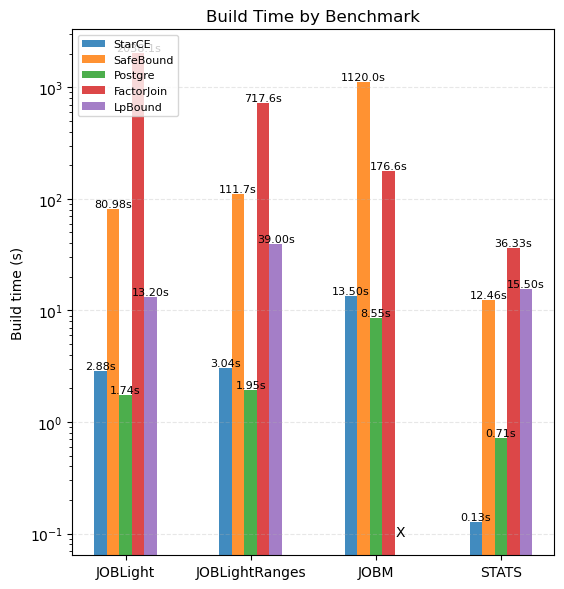

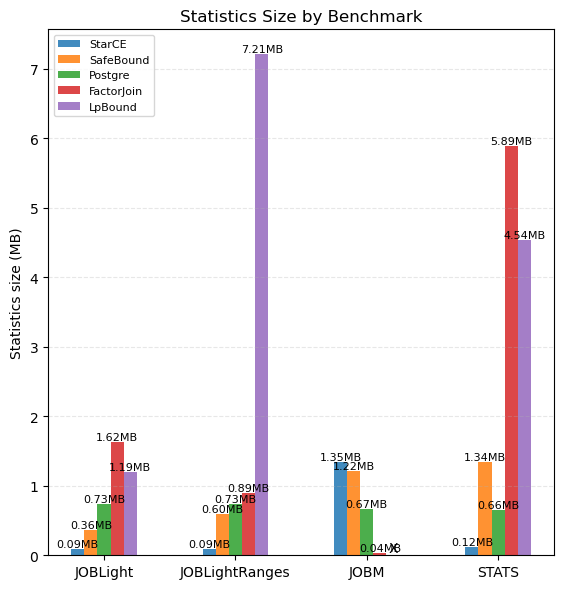

In [4]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages


def plot_grouped(metric_col, missing_col, ylabel, title, formatter, log_scale=False):
    method_names = list(methods.keys())
    x = np.arange(len(benchmarks))
    width = 0.5 / max(len(method_names), 1)

    fig, ax = plt.subplots(figsize=(7, 6))

    min_pos = None
    if log_scale:
        for _, row in results_df.iterrows():
            val = row.get(metric_col)
            missing = bool(row.get(missing_col))
            if not missing and val is not None:
                try:
                    val_num = float(val)
                except (TypeError, ValueError):
                    continue
                if val_num > 0:
                    min_pos = val_num if min_pos is None else min(min_pos, val_num)
        if min_pos is None:
            min_pos = 1.0
        y_missing = min_pos * 0.7
    else:
        y_missing = 0

    for i, method_name in enumerate(method_names):
        values = []
        missing_flags = []
        for benchmark in benchmarks:
            row = results_df[
                (results_df["method"] == method_name)
                & (results_df["benchmark"] == benchmark)
            ]
            if row.empty:
                values.append(0)
                missing_flags.append(True)
            else:
                val = row.iloc[0][metric_col]
                missing = bool(row.iloc[0][missing_col])
                if missing or val is None:
                    values.append(np.nan if log_scale else 0)
                else:
                    values.append(float(val))
                missing_flags.append(missing)

        offset = (i - (len(method_names) - 1) / 2) * width
        positions = x + offset
        bars = ax.bar(positions, values, width, label=method_name, alpha=0.85)

        for pos, val, missing in zip(positions, values, missing_flags):
            if missing:
                ax.text(pos, y_missing, "X", ha="center", va="bottom")
            else:
                ax.text(pos, val, formatter(val), ha="center", va="bottom", fontsize=8)

    if log_scale:
        ax.set_yscale("log")
        ax.set_ylim(bottom=min_pos * 0.5)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(benchmarks)
    ax.legend(loc="upper left", fontsize=8, ncol=1)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout(rect=(0, 0, 0.82, 1))
    return fig, ax


def format_time_label(value):
    if value < 100:
        return f"{value:.2f}s"
    return f"{value:.1f}s"


def format_size_label(value):
    if value < 100:
        return f"{value:.2f}{size_unit}"
    return f"{value:.1f}{size_unit}"


results_df["statistics_size_unit"] = results_df["statistics_size_bytes"].apply(size_to_unit)

fig_time, _ = plot_grouped(
    metric_col="build_time_sec",
    missing_col="build_missing",
    ylabel="Build time (s)",
    title="Build Time by Benchmark",
    formatter=format_time_label,
    log_scale=True,
)

fig_size, _ = plot_grouped(
    metric_col="statistics_size_unit",
    missing_col="size_missing",
    ylabel=f"Statistics size ({size_unit})",
    title="Statistics Size by Benchmark",
    formatter=format_size_label,
)

pdf_path = checkpoint_root / "EvaluateBuild" / "EvaluateBuild.pdf"
with PdfPages(pdf_path) as pdf:
    pdf.savefig(fig_time)
    pdf.savefig(fig_size)
print(f"Saved to {pdf_path}")